# 02: Time Series Econometrics

Data: panel_monthly_var
Period: 2017-01–2024-12
N: 96 monthly obs

In [1]:
# ============================================================
# NOTEBOOK 2 — ÉCONOMÉTRIE TEMPORELLE
# VAR mensuel · Causalité de Granger · IRF · FEVD
# ============================================================
#
# QUESTION CENTRALE :
#   Le pétrole drive-t-il l'intégralité de la relation commerciale
#   Russie-Chine, ou existe-t-il un facteur géopolitique autonome
#   (effet "sanctions / pivot vers l'Est") ?
#
# APPROCHE MÉTHODOLOGIQUE :
#   1. Construction d'un panel mensuel (Comtrade, FRED, Investing)
#   2. Tests de stationnarité (ADF + KPSS, confirmation croisée)
#   3. Test de cointégration (Johansen) → choix VAR vs VECM
#   4. Estimation VAR en différences (prudent avec N=96)
#   5. Causalité de Granger
#   6. IRF + FEVD (décomposition de la variance)
#   7. Analyse de rupture structurelle (pré/post fév 2022)
#
# CAVEAT : N=96 mensuels est un petit échantillon pour un VAR.
#   Les résultats sont exploratoires, pas confirmatoires.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
import gc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*p-value is smaller.*")
warnings.filterwarnings("ignore", message=".*p-value is greater.*")

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 80,
    "savefig.bbox": "tight",
    "savefig.dpi": 120,
})

_candidates = [Path.cwd(), Path.cwd().parent]
for c in _candidates:
    _proj = c / "russia_china_dependency"
    if _proj.exists() and (_proj / "01_raw_data").exists():
        PROJECT_ROOT = c
        break
else:
    PROJECT_ROOT = Path.cwd()

PROJECT = PROJECT_ROOT / "russia_china_dependency"
RAW = PROJECT / "01_raw_data"
PROCESSED = PROJECT / "02_processed_data"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

EVENTS = {
    "2014-03-01": ("Annexion Crimée", "gray"),
    "2018-04-01": ("Sanctions US (avril 2018)", "orange"),
    "2020-03-01": ("COVID-19", "gray"),
    "2022-02-24": ("Invasion Ukraine", "red"),
    "2022-06-01": ("Embargo UE pétrole", "darkred"),
}

print(f"Setup OK | Root: {PROJECT_ROOT}")
print(f"Figures -> {FIGURES}")


Setup OK | Racine: d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie
Figures -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\reports\figures


In [2]:
# ============================================================
# Load & build monthly panel
# ============================================================
# CORRECTION CRITIQUE : aggrLevel == 0 pour eviter le 4x overcounting.
# ============================================================

ct = pd.read_csv(
    RAW / "trade" / "comtrade_detailed_2013_2024.csv",
    usecols=["freqCode", "period", "flowCode", "reporterISO",
             "partnerISO", "primaryValue", "aggrLevel"],
)
ct_monthly = ct[(ct["freqCode"] == "M") & (ct["aggrLevel"] == 0)].copy()

trade_monthly = (
    ct_monthly.groupby(["period", "flowCode", "reporterISO", "partnerISO"])
    ["primaryValue"].sum().reset_index()
)

chn_exp = trade_monthly[
    (trade_monthly["reporterISO"] == "CHN")
    & (trade_monthly["partnerISO"] == "RUS")
    & (trade_monthly["flowCode"] == "X")
][["period", "primaryValue"]].rename(columns={"primaryValue": "CHN_exports_to_RUS"})
chn_exp["date"] = pd.to_datetime(chn_exp["period"].astype(str), format="%Y%m")

chn_imp = trade_monthly[
    (trade_monthly["reporterISO"] == "CHN")
    & (trade_monthly["partnerISO"] == "RUS")
    & (trade_monthly["flowCode"] == "M")
][["period", "primaryValue"]].rename(columns={"primaryValue": "CHN_imports_from_RUS"})

if len(chn_imp) == 0:
    _imp_file = RAW / "trade" / "comtrade_imports_chn_from_rus_2017_2024.csv"
    if _imp_file.exists():
        _imp = pd.read_csv(_imp_file)
        if "primaryValue" in _imp.columns and "period" in _imp.columns:
            chn_imp = (
                _imp.groupby("period")["primaryValue"].sum().reset_index()
                .rename(columns={"primaryValue": "CHN_imports_from_RUS"})
            )
            print(f"Imports charges depuis fichier separe ({len(chn_imp)} mois)")

has_imports = len(chn_imp) > 0
if has_imports:
    chn_imp["date"] = pd.to_datetime(chn_imp["period"].astype(str), format="%Y%m")
    trade = (
        chn_exp[["date", "CHN_exports_to_RUS"]]
        .merge(chn_imp[["date", "CHN_imports_from_RUS"]], on="date", how="outer")
        .sort_values("date").set_index("date")
    )
    trade = trade / 1e9
    trade.columns = ["CHN_exp_to_RUS_bn", "RUS_exp_to_CHN_bn"]
else:
    trade = chn_exp[["date", "CHN_exports_to_RUS"]].sort_values("date").set_index("date") / 1e9
    trade.columns = ["CHN_exp_to_RUS_bn"]

print(f"Commerce : {len(trade)} mois, {trade.index.min():%Y-%m} -> {trade.index.max():%Y-%m}")

# Brent
brent = pd.read_csv(RAW / "prices" / "brent_oil_daily.csv")
brent["date"] = pd.to_datetime(brent["observation_date"])
brent = brent[["date", "DCOILBRENTEU"]].set_index("date").replace(".", np.nan).astype(float)
brent_m = brent.resample("MS").mean().rename(columns={"DCOILBRENTEU": "brent_usd"})

# USD/RUB (FRED + Investing)
rub_parts = []
_fred_rub = RAW / "prices" / "usd_rub_fred.csv"
if _fred_rub.exists():
    rub_fred = pd.read_csv(_fred_rub)
    _val_col = [c for c in rub_fred.columns if c != "observation_date"][0]
    rub_fred["date"] = pd.to_datetime(rub_fred["observation_date"])
    rub_fred = rub_fred[["date", _val_col]].set_index("date").replace(".", np.nan).astype(float)
    rub_parts.append(rub_fred.resample("MS").mean().rename(columns={_val_col: "usd_rub"}))

_inv_rub_paths = [RAW / "prices" / "usd_rub_investing.csv", RAW / "macro" / "usd_rub_investing.csv"]
_inv_rub = next((p for p in _inv_rub_paths if p.exists()), None)
if _inv_rub is not None:
    rub_inv = pd.read_csv(_inv_rub)
    rub_inv["date"] = pd.to_datetime(rub_inv["Date"], format="mixed", dayfirst=False)
    rub_inv = rub_inv[["date", "Price"]].set_index("date").sort_index()
    rub_parts.append(rub_inv.resample("MS").mean().rename(columns={"Price": "usd_rub"}))

assert rub_parts, "USD/RUB introuvable."
rub_m = pd.concat(rub_parts).sort_index()
rub_m = rub_m[~rub_m.index.duplicated(keep="first")].asfreq("MS").interpolate(method="linear", limit=3)

# USD/CNY
_cny_paths = [RAW / "prices" / "usd_cny_daily.csv", RAW / "macro" / "usd_cny_daily.csv"]
cny_path = next((p for p in _cny_paths if p.exists()), None)
assert cny_path, "USD/CNY introuvable."
cny = pd.read_csv(cny_path)
cny["date"] = pd.to_datetime(cny["observation_date"])
cny = cny[["date", "DEXCHUS"]].set_index("date").replace(".", np.nan).astype(float)
cny_m = cny.resample("MS").mean().rename(columns={"DEXCHUS": "usd_cny"})

# Fusion + log-transform
panel = trade.join([brent_m, rub_m, cny_m], how="inner")
core_cols = ["CHN_exp_to_RUS_bn", "brent_usd", "usd_rub", "usd_cny"]
panel = panel.dropna(subset=core_cols).asfreq("MS")
for col in panel.columns:
    panel[f"ln_{col}"] = np.log(panel[col])

print(f"Panel : {len(panel)} obs, {panel.index.min():%Y-%m} -> {panel.index.max():%Y-%m}")
print(f"Colonnes : {[c for c in panel.columns if not c.startswith('ln_')]}")
print(panel[[c for c in panel.columns if not c.startswith("ln_")]].describe().round(3))
panel.head()


Imports charges depuis fichier separe (96 mois)
Commerce : 96 mois, 2017-01 -> 2024-12
Panel : 96 obs, 2017-01 -> 2024-12
Colonnes : ['CHN_exp_to_RUS_bn', 'RUS_exp_to_CHN_bn', 'brent_usd', 'usd_rub', 'usd_cny']
       CHN_exp_to_RUS_bn  RUS_exp_to_CHN_bn  brent_usd  usd_rub  usd_cny
count             96.000             96.000     96.000   96.000   96.000
mean               5.835              7.004     70.733   72.390    6.829
std                2.483              2.882     18.729   12.887    0.293
min                1.578              2.938     18.378   51.158    6.297
25%                3.994              4.665     59.318   62.716    6.587
50%                4.731              5.764     72.317   70.429    6.873
75%                7.905              9.950     81.871   79.420    7.077
max               11.297             12.182    122.711  113.496    7.307


,CHN_exp_to_RUS_bn,RUS_exp_to_CHN_bn,brent_usd,usd_rub,usd_cny,ln_CHN_exp_to_RUS_bn,ln_RUS_exp_to_CHN_bn,ln_brent_usd,ln_usd_rub,ln_usd_cny
date,,,,,,,,,,
2017-01-01,3.335332,3.159814,54.576667,60.1618,6.890663,1.204572,1.150513,3.999606,4.097038,1.930167
2017-02-01,1.991554,3.025373,54.869500,57.9371,6.869426,0.688915,1.107034,4.004958,4.059358,1.927081
2017-03-01,2.971963,3.497522,51.589130,56.3779,6.894000,1.089223,1.252055,3.943311,4.032077,1.930651
2017-04-01,3.168361,3.339517,52.307895,56.9838,6.887555,1.153214,1.205826,3.957147,4.042767,1.929716
2017-05-01,3.691495,3.846448,50.326522,56.5168,6.884305,1.306031,1.347150,3.918532,4.034538,1.929244


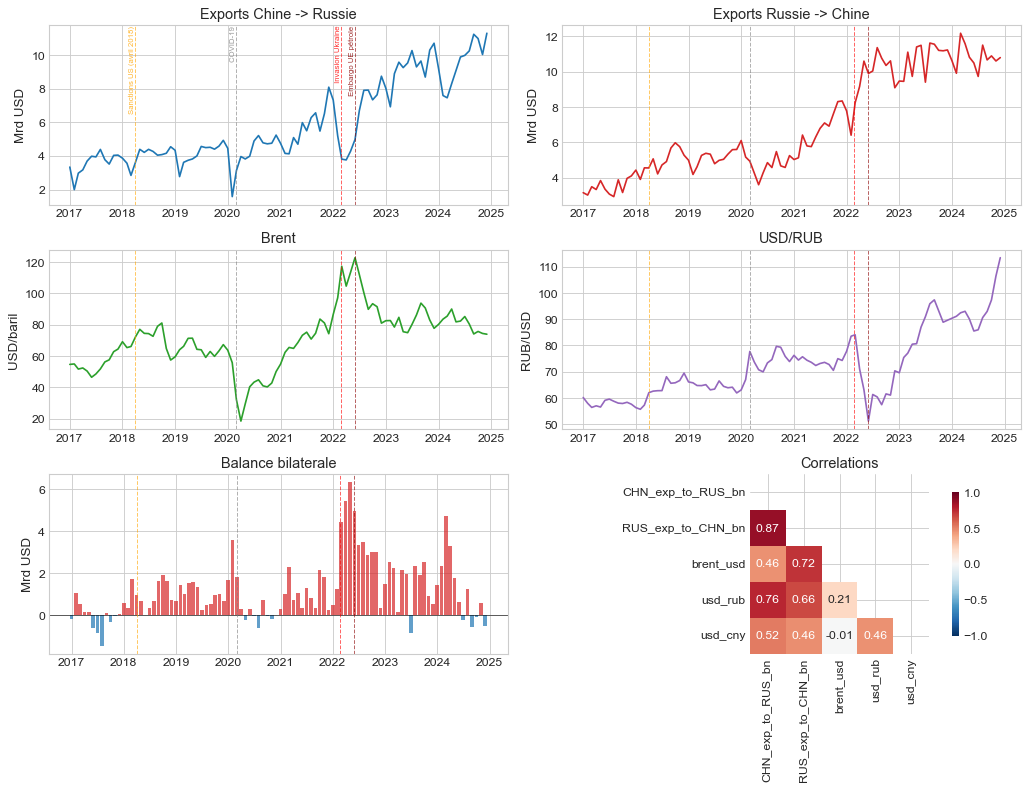

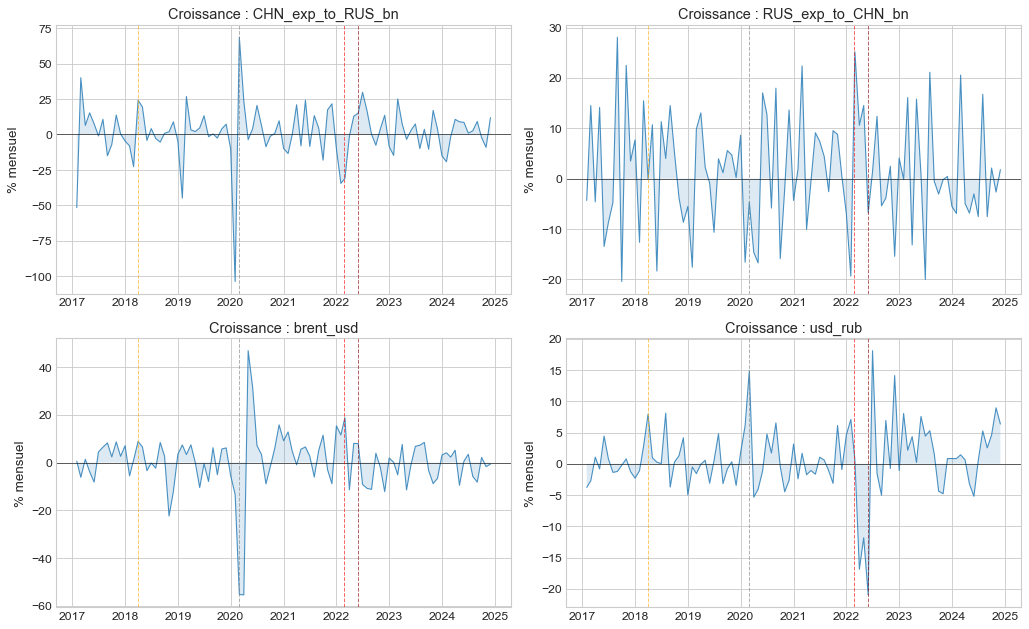

Figures sauvegardees.


In [3]:
# ============================================================
# VISUALISATION EXPLORATOIRE
# ============================================================

def _add_events(ax, show_label=False):
    for date_str, (label, color) in EVENTS.items():
        ts = pd.Timestamp(date_str)
        if panel.index.min() <= ts <= panel.index.max():
            ax.axvline(ts, color=color, linestyle="--", alpha=0.6, lw=0.9)
            if show_label:
                ax.text(ts, ax.get_ylim()[1], f" {label}", rotation=90,
                        va="top", ha="right", fontsize=7, color=color, alpha=0.8)

_has_imp = "RUS_exp_to_CHN_bn" in panel.columns
_raw_cols = [c for c in panel.columns if not c.startswith("ln_")]

# Figure 1 : series en niveaux
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(panel.index, panel["CHN_exp_to_RUS_bn"], color="#1f77b4", lw=1.5)
ax.set_ylabel("Mrd USD"); ax.set_title("Exports Chine -> Russie")
_add_events(ax, show_label=True)

ax = axes[0, 1]
if _has_imp:
    ax.plot(panel.index, panel["RUS_exp_to_CHN_bn"], color="#d62728", lw=1.5)
    ax.set_title("Exports Russie -> Chine")
else:
    ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
ax.set_ylabel("Mrd USD"); _add_events(ax)

ax = axes[1, 0]
ax.plot(panel.index, panel["brent_usd"], color="#2ca02c", lw=1.5)
ax.set_ylabel("USD/baril"); ax.set_title("Brent"); _add_events(ax)

ax = axes[1, 1]
ax.plot(panel.index, panel["usd_rub"], color="#9467bd", lw=1.5)
ax.set_ylabel("RUB/USD"); ax.set_title("USD/RUB"); _add_events(ax)

ax = axes[2, 0]
if _has_imp:
    balance = panel["RUS_exp_to_CHN_bn"] - panel["CHN_exp_to_RUS_bn"]
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in balance]
    ax.bar(panel.index, balance, width=25, color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Mrd USD"); ax.set_title("Balance bilaterale"); _add_events(ax)

ax = axes[2, 1]
corr = panel[_raw_cols].corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlations")

plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig1_niveaux.png")
plt.show(); plt.close("all"); gc.collect()

# Figure 2 : taux de croissance
log_cols = [c for c in panel.columns if c.startswith("ln_")]
dlog_viz = panel[log_cols].diff().dropna() * 100
dlog_viz.columns = [c.replace("ln_", "growth_") for c in dlog_viz.columns]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, dlog_viz.columns):
    ax.plot(dlog_viz.index, dlog_viz[col], lw=1, alpha=0.8)
    ax.axhline(0, color="black", lw=0.5)
    ax.fill_between(dlog_viz.index, dlog_viz[col], 0, alpha=0.15)
    ax.set_ylabel("% mensuel")
    ax.set_title(col.replace("growth_", "Croissance : "))
    _add_events(ax)

plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig2_growth_rates.png")
plt.show(); plt.close("all"); gc.collect()
print("Figures saved.")


In [4]:
# ============================================================
# TESTS DE STATIONNARITE (ADF + KPSS)
# ============================================================

def stationarity_battery(series, name, alpha=0.05):
    s = series.dropna()
    r = {}
    adf_stat, adf_p, adf_lags, adf_n, adf_cv, _ = adfuller(s, autolag="AIC")
    r["ADF_stat"], r["ADF_p"], r["ADF_lags"] = adf_stat, adf_p, adf_lags
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression="c", nlags="auto")
    r["KPSS_stat"], r["KPSS_p"] = kpss_stat, kpss_p
    adf_rej = adf_p < alpha
    kpss_rej = kpss_p < alpha
    if adf_rej and not kpss_rej:
        r["verdict"] = "I(0) STATIONNAIRE"
    elif not adf_rej and kpss_rej:
        r["verdict"] = "I(1) NON-STATIONNAIRE"
    elif adf_rej and kpss_rej:
        r["verdict"] = "AMBIGU (trend-stat?)"
    else:
        r["verdict"] = "AMBIGU (faible puissance)"
    return r

def _fmt_kpss(p):
    if p <= 0.01: return "<.01"
    if p >= 0.10: return ">.10"
    return f"{p:.3f}"

_log_vars = {c: c.replace("ln_", "ln(") + ")" for c in panel.columns if c.startswith("ln_")}

header = f"{'Variable':<28} {'ADF stat':>9} {'ADF p':>7} {'KPSS stat':>10} {'KPSS p':>7}  {'Verdict'}"
print("=" * 90); print("A. NIVEAUX (log)"); print("=" * 90); print(header); print("-" * 90)

stationarity_results = {}
for col, label in _log_vars.items():
    r = stationarity_battery(panel[col], col)
    stationarity_results[col] = r
    print(f"  {label:<26} {r['ADF_stat']:>9.3f} {r['ADF_p']:>7.4f} "
          f"{r['KPSS_stat']:>10.3f} {_fmt_kpss(r['KPSS_p']):>7}  {r['verdict']}")

print(f"\n{'='*90}"); print("B. DIFFERENCES (dlog)"); print("=" * 90); print(header); print("-" * 90)
for col, label in _log_vars.items():
    d = panel[col].diff().dropna()
    r = stationarity_battery(d, f"d_{col}")
    stationarity_results[f"d_{col}"] = r
    print(f"  d{label:<25} {r['ADF_stat']:>9.3f} {r['ADF_p']:>7.4f} "
          f"{r['KPSS_stat']:>10.3f} {_fmt_kpss(r['KPSS_p']):>7}  {r['verdict']}")

n_i1 = sum(1 for k, v in stationarity_results.items() if not k.startswith("d_") and "I(1)" in v["verdict"])
n_i0 = sum(1 for k, v in stationarity_results.items() if k.startswith("d_") and "I(0)" in v["verdict"])
print(f"\n-> {n_i1}/{len(_log_vars)} series I(1) en niveaux, {n_i0}/{len(_log_vars)} I(0) en differences.")


A. NIVEAUX (log)
Variable                      ADF stat   ADF p  KPSS stat  KPSS p  Verdict
------------------------------------------------------------------------------------------
  ln(CHN_exp_to_RUS_bn)          0.526  0.9856      1.521    <.01  I(1) NON-STATIONNAIRE
  ln(RUS_exp_to_CHN_bn)         -1.422  0.5719      1.561    <.01  I(1) NON-STATIONNAIRE
  ln(brent_usd)                 -2.105  0.2424      0.624   0.020  I(1) NON-STATIONNAIRE
  ln(usd_rub)                   -0.495  0.8931      1.205    <.01  I(1) NON-STATIONNAIRE
  ln(usd_cny)                   -2.129  0.2330      0.440   0.060  AMBIGU (faible puissance)

B. DIFFERENCES (dlog)
Variable                      ADF stat   ADF p  KPSS stat  KPSS p  Verdict
------------------------------------------------------------------------------------------
  dln(CHN_exp_to_RUS_bn)        -5.888  0.0000      0.128    >.10  I(0) STATIONNAIRE
  dln(RUS_exp_to_CHN_bn)       -13.174  0.0000      0.079    >.10  I(0) STATIONNAIRE
  dln(bre

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_1460\2052613652.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression="c", nlags="auto")
C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_1460\2052613652.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression="c", nlags="auto")
C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_1460\2052613652.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression="c", nlags="auto")
C:\Users\Proprietaire\AppData\Local\T

In [ ]:
# ============================================================
# TEST DE COINTEGRATION DE JOHANSEN
# ============================================================

_log_trade = "ln_RUS_exp_to_CHN_bn" if "ln_RUS_exp_to_CHN_bn" in panel.columns else "ln_CHN_exp_to_RUS_bn"
coint_cols = [_log_trade, "ln_brent_usd", "ln_usd_rub"]
coint_data = panel[coint_cols].dropna()

_var_levels = VAR(coint_data)
_lag_results = _var_levels.select_order(maxlags=8)
print("Selection du lag order (VAR en niveaux log) :")
print(_lag_results.summary())
_best_lag = max(1, _lag_results.aic)
print(f"\n-> Lag retenu pour Johansen : {_best_lag} (AIC)")

johansen_result = coint_johansen(coint_data, det_order=-1, k_ar_diff=_best_lag)

print(f"\n{'='*70}")
print(f"TEST DE JOHANSEN | N={len(coint_data)}, lags={_best_lag}, det_order=-1")
print(f"{'='*70}")

for test_name, stat_arr, cv_arr in [
    ("Trace", johansen_result.trace_stat, johansen_result.trace_stat_crit_vals),
    ("Max-Eigen", johansen_result.max_eig_stat, johansen_result.max_eig_stat_crit_vals),
]:
    print(f"\n{'Rang r':<8} {test_name:>12} {'CV 5%':>10} {'CV 1%':>10} {'Rejet ?':>12}")
    print("-" * 55)
    for i in range(len(stat_arr)):
        s = stat_arr[i]; cv5, cv1 = cv_arr[i, 1], cv_arr[i, 2]
        flag = "*** (1%)" if s > cv1 else ("** (5%)" if s > cv5 else "Non")
        print(f"  r={i:<5} {s:>12.3f} {cv5:>10.3f} {cv1:>10.3f} {flag:>12}")

coint_rank = 0
for i in range(len(johansen_result.trace_stat)):
    if johansen_result.trace_stat[i] > johansen_result.trace_stat_crit_vals[i, 1]:
        coint_rank = i + 1
    else: break

print(f"\n-> Rang de cointegration = {coint_rank}")
if coint_rank > 0:
    print("  Relation de long terme detectee, mais avec N=96, VAR en differences plus prudent.")
else:
    print("  Pas de cointegration -> VAR en differences confirme.")


Selection du lag order (VAR en niveaux log) :
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -9.210      -9.125   0.0001000      -9.176
1      -14.41      -14.08   5.503e-07      -14.28
2      -14.69     -14.10*   4.187e-07     -14.45*
3     -14.77*      -13.93  3.847e-07*      -14.43
4      -14.63      -13.54   4.440e-07      -14.19
5      -14.64      -13.29   4.445e-07      -14.09
6      -14.61      -13.01   4.599e-07      -13.97
7      -14.60      -12.74   4.709e-07      -13.85
8      -14.52      -12.41   5.179e-07      -13.67
-------------------------------------------------

-> Lag retenu pour Johansen : 3 (AIC)

TEST DE JOHANSEN | N=96, lags=3, det_order=-1

Rang r          Trace      CV 5%      CV 1%      Rejet ?
-------------------------------------------------------
  r=0           18.061     24.276     29.515          Non
  r=1            7.154     12.321     16.364  

In [6]:
# ============================================================
# ESTIMATION VAR EN DIFFERENCES (dlog)
# Ordering Cholesky : Brent -> USD/RUB -> USD/CNY -> Commerce
# ============================================================

_log_trade_col = "ln_RUS_exp_to_CHN_bn" if "ln_RUS_exp_to_CHN_bn" in panel.columns else "ln_CHN_exp_to_RUS_bn"
var_cols = ["ln_brent_usd", "ln_usd_rub", "ln_usd_cny", _log_trade_col]
var_labels = ["Brent", "USD/RUB", "USD/CNY",
              "Exp RUS->CHN" if "RUS" in _log_trade_col else "Exp CHN->RUS"]

dlog = panel[var_cols].diff().dropna()
dlog.columns = [f"d_{c}" for c in var_cols]
print(f"Donnees VAR : {dlog.shape[0]} obs x {dlog.shape[1]} variables")
print(f"Ordering Cholesky : {' -> '.join(var_labels)}")

model_select = VAR(dlog)
lag_order = model_select.select_order(maxlags=6)
print(f"\nSelection du lag order :"); print(lag_order.summary())
p_aic = max(1, lag_order.aic)
p_bic = max(1, lag_order.bic)
p_chosen = p_aic
print(f"\n-> Ordre retenu : p={p_chosen} (AIC={p_aic}, BIC={p_bic})")

var_model = model_select.fit(maxlags=p_chosen, ic=None)
print(f"\nVAR({p_chosen}) estime : {var_model.nobs} obs, AIC={var_model.aic:.2f}")

# Diagnostics residus
print(f"\n{'='*70}"); print("DIAGNOSTICS DES RESIDUS"); print(f"{'='*70}")
resid = pd.DataFrame(var_model.resid, columns=dlog.columns)

dw_stats = durbin_watson(var_model.resid)
print(f"\n{'Equation':<30} {'Durbin-Watson':>14}")
print("-" * 50)
for i, (col, dw) in enumerate(zip(dlog.columns, dw_stats)):
    interp = "OK (~2)" if 1.5 < dw < 2.5 else "autocorrelation!"
    print(f"  {var_labels[i]:<28} {dw:>14.3f}  {interp}")

print(f"\n{'Equation':<30} {'LB stat (12)':>14} {'p-value':>10}")
print("-" * 55)
for i, col in enumerate(dlog.columns):
    lb = acorr_ljungbox(resid[col], lags=12, return_df=True)
    print(f"  {var_labels[i]:<28} {lb['lb_stat'].iloc[-1]:>14.2f} {lb['lb_pvalue'].iloc[-1]:>10.4f}")

print(f"\n{'Equation':<30} {'JB stat':>10} {'p-value':>10} {'Normal?':>10}")
print("-" * 65)
for i, col in enumerate(dlog.columns):
    jb_s, jb_p = stats.jarque_bera(resid[col])
    print(f"  {var_labels[i]:<28} {jb_s:>10.2f} {jb_p:>10.4f} {'Oui' if jb_p > 0.05 else 'Non':>10}")


Donnees VAR : 95 obs x 4 variables
Ordering Cholesky : Brent -> USD/RUB -> USD/CNY -> Exp RUS->CHN

Selection du lag order :
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -22.99     -22.88*   1.036e-10      -22.95
1      -23.42      -22.86   6.733e-11     -23.20*
2     -23.47*      -22.47  6.418e-11*      -23.07
3      -23.27      -21.81   7.923e-11      -22.68
4      -23.23      -21.33   8.335e-11      -22.46
5      -23.25      -20.90   8.275e-11      -22.30
6      -23.26      -20.46   8.422e-11      -22.13
-------------------------------------------------

-> Ordre retenu : p=2 (AIC=2, BIC=1)

VAR(2) estime : 93 obs, AIC=-23.58

DIAGNOSTICS DES RESIDUS

Equation                        Durbin-Watson
--------------------------------------------------
  Brent                                 2.062  OK (~2)
  USD/RUB                               1.908  OK (~2)
  USD/CNY         

In [ ]:
# ============================================================
# CAUSALITE DE GRANGER
# ============================================================

print(f"{'='*80}"); print(f"TESTS DE GRANGER (lag = {p_chosen})"); print(f"{'='*80}")

gc_results = {}
dlog_cols = list(dlog.columns)
print(f"\n{'Cause -> Effet':<45} {'F-stat':>8} {'p-value':>9} {'Sig?':>10}")
print("-" * 75)

for i, cause in enumerate(dlog_cols):
    for j, effect in enumerate(dlog_cols):
        if i == j: continue
        data_gc = dlog[[effect, cause]].dropna()
        try:
            gc = grangercausalitytests(data_gc, maxlag=p_chosen, verbose=False)
            f_stat = gc[p_chosen][0]["ssr_ftest"][0]
            f_pval = gc[p_chosen][0]["ssr_ftest"][1]
            gc_results[(cause, effect)] = {"F": f_stat, "p": f_pval}
            sig = "***" if f_pval < 0.01 else ("**" if f_pval < 0.05 else ("*" if f_pval < 0.10 else ""))
            print(f"  {var_labels[i]} -> {var_labels[j]:<28} {f_stat:>8.2f} {f_pval:>9.4f} {sig:>10}")
        except Exception as e:
            print(f"  {var_labels[i]} -> {var_labels[j]:<28} ERREUR")

# Question cle
_brent_to_trade = gc_results.get((dlog_cols[0], dlog_cols[-1]), {})
if _brent_to_trade:
    p_bt = _brent_to_trade["p"]
    print(f"\n-> Brent -> Commerce : p={p_bt:.4f}", end="")
    print(" => OUI, le petrole predit le commerce" if p_bt < 0.10 else " => NON significatif")


TESTS DE GRANGER (lag = 2)

Cause -> Effet                                  F-stat   p-value       Sig?
---------------------------------------------------------------------------
  Brent -> USD/RUB                          0.27    0.7674           
  Brent -> USD/CNY                          0.29    0.7505           
  Brent -> Exp RUS->CHN                    17.20    0.0000        ***
  USD/RUB -> Brent                            2.33    0.1037           
  USD/RUB -> USD/CNY                          1.79    0.1723           
  USD/RUB -> Exp RUS->CHN                     1.33    0.2705           
  USD/CNY -> Brent                            0.35    0.7042           
  USD/CNY -> USD/RUB                          0.55    0.5809           
  USD/CNY -> Exp RUS->CHN                     0.19    0.8304           
  Exp RUS->CHN -> Brent                            0.01    0.9898           
  Exp RUS->CHN -> USD/RUB                          0.93    0.3976           
  Exp RUS->CHN -> USD/CN

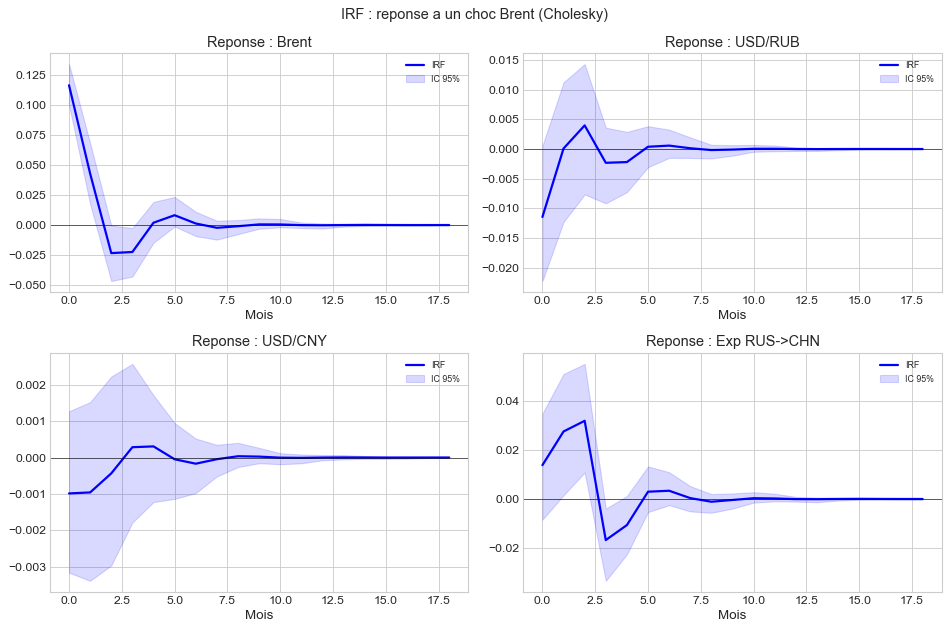

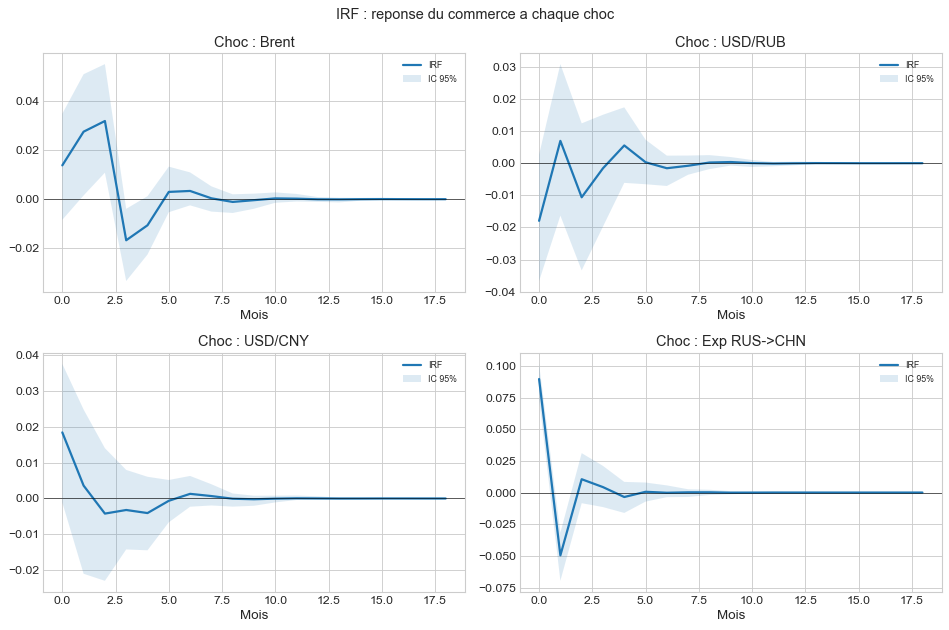


FEVD du commerce bilateral :
  h= 1 : Brent: 2.2%  USD/RUB: 3.6%  USD/CNY: 3.8%  Exp RUS->CHN: 90.4%
  h= 3 : Brent: 14.7%  USD/RUB: 3.6%  USD/CNY: 2.8%  Exp RUS->CHN: 78.9%
  h= 6 : Brent: 17.1%  USD/RUB: 3.7%  USD/CNY: 2.9%  Exp RUS->CHN: 76.3%
  h=12 : Brent: 17.2%  USD/RUB: 3.7%  USD/CNY: 2.9%  Exp RUS->CHN: 76.2%
  h=18 : Brent: 17.2%  USD/RUB: 3.7%  USD/CNY: 2.9%  Exp RUS->CHN: 76.2%


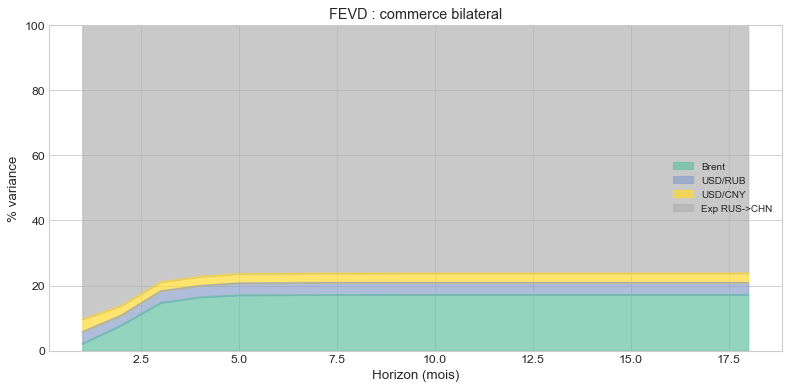


-> A 12 mois : Brent = 17.2%, propres chocs = 76.2%


In [8]:
# ============================================================
# IRF & FEVD
# ============================================================

import gc as gc_module

H = 18
irf = var_model.irf(H)
mc_lower, mc_upper = irf.errband_mc(orth=True, repl=500, signif=0.05)

# Figure 3 : reponse a un choc Brent
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("IRF : reponse a un choc Brent (Cholesky)", fontsize=13)
for idx, (ax, label) in enumerate(zip(axes.flat, var_labels)):
    resp = irf.orth_irfs[:, idx, 0]
    ax.plot(range(H+1), resp, "b-", lw=2, label="IRF")
    ax.fill_between(range(H+1), mc_lower[:, idx, 0], mc_upper[:, idx, 0],
                    alpha=0.15, color="blue", label="IC 95%")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Reponse : {label}"); ax.set_xlabel("Mois")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig3_irf_brent.png")
plt.show(); plt.close("all"); gc_module.collect()

# Figure 4 : reponse du commerce a chaque choc
trade_idx = len(var_labels) - 1
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("IRF : reponse du commerce a chaque choc", fontsize=13)
for imp_idx, (ax, label) in enumerate(zip(axes.flat, var_labels)):
    resp = irf.orth_irfs[:, trade_idx, imp_idx]
    ax.plot(range(H+1), resp, lw=2, label="IRF")
    ax.fill_between(range(H+1), mc_lower[:, trade_idx, imp_idx],
                    mc_upper[:, trade_idx, imp_idx], alpha=0.15, label="IC 95%")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Choc : {label}"); ax.set_xlabel("Mois"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig4_irf_trade.png")
plt.show(); plt.close("all"); gc_module.collect()

# FEVD
fevd = var_model.fevd(H)
fevd_trade = pd.DataFrame(fevd.decomp[trade_idx], columns=var_labels, index=range(1, H+1))
print(f"\nFEVD du commerce bilateral :")
for h in [1, 3, 6, 12, 18]:
    if h <= H:
        row = fevd_trade.loc[h]
        print(f"  h={h:>2} : " + "  ".join([f"{l}: {v*100:.1f}%" for l, v in row.items()]))

fig, ax = plt.subplots(figsize=(10, 5))
(fevd_trade * 100).plot.area(ax=ax, alpha=0.7, colormap="Set2")
ax.set_ylabel("% variance"); ax.set_xlabel("Horizon (mois)")
ax.set_title("FEVD : commerce bilateral"); ax.set_ylim(0, 100)
ax.legend(loc="center right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig5_fevd.png")
plt.show(); plt.close("all"); gc_module.collect()

brent_share_12 = fevd_trade.loc[min(12, H)].iloc[0] * 100
own_share_12 = fevd_trade.loc[min(12, H)].iloc[-1] * 100
print(f"\n-> A 12 mois : Brent = {brent_share_12:.1f}%, propres chocs = {own_share_12:.1f}%")


Pre  : 61 mois | Post : 35 mois
                   Pre (moy)  Post (moy)  Var (%)
CHN_exp_to_RUS_bn       4.35        8.42    93.32
RUS_exp_to_CHN_bn       5.03       10.44   107.49
brent_usd              60.85       87.96    44.57
usd_rub                66.69       82.32    23.42
usd_cny                 6.72        7.02     4.49

TEST DE CHOW

Equation                           F-Chow    p-value     Rupture?
-----------------------------------------------------------------
  Brent                             2.130     0.0370          OUI
  USD/RUB                           2.146     0.0356          OUI
  USD/CNY                           1.145     0.3424          Non
  Exp RUS->CHN                      2.125     0.0375          OUI


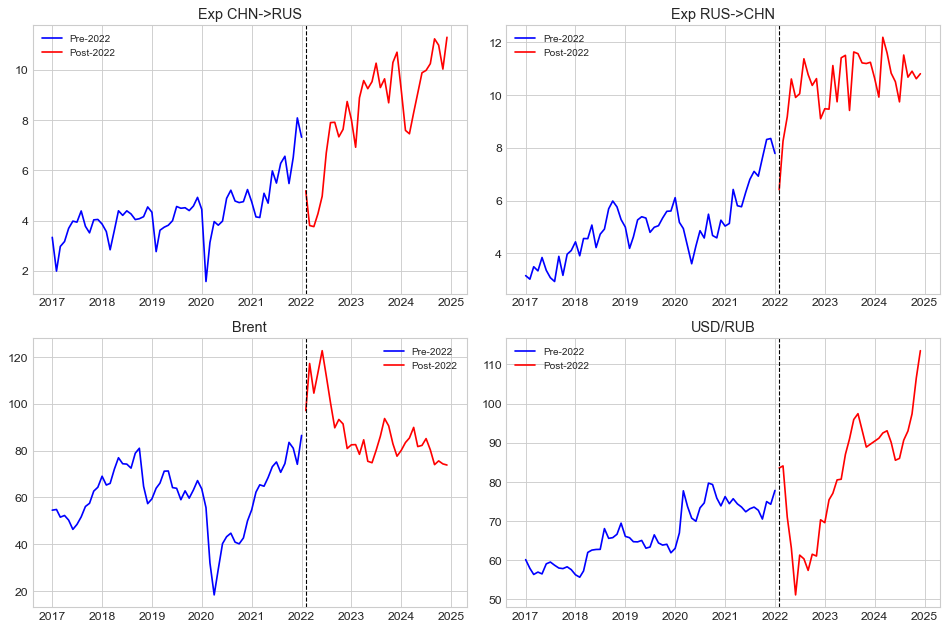


-> 3/4 equations avec rupture significative (5%).


In [ ]:
# ============================================================
# RUPTURE STRUCTURELLE (Chow test, fev 2022)
# ============================================================

BREAK_DATE = pd.Timestamp("2022-02-01")
pre = panel[panel.index < BREAK_DATE]
post = panel[panel.index >= BREAK_DATE]

_raw_cols = [c for c in panel.columns if not c.startswith("ln_")]
print(f"Pre  : {len(pre)} mois | Post : {len(post)} mois")

comp = pd.DataFrame({
    "Pre (moy)": pre[_raw_cols].mean(),
    "Post (moy)": post[_raw_cols].mean(),
    "Var (%)": ((post[_raw_cols].mean() - pre[_raw_cols].mean()) / pre[_raw_cols].mean() * 100),
})
print(comp.round(2))

# Test de Chow
print(f"\n{'='*70}"); print("TEST DE CHOW"); print(f"{'='*70}")
dlog_pre = dlog[dlog.index < BREAK_DATE]
dlog_post = dlog[dlog.index >= BREAK_DATE]
rss_full = np.sum(var_model.resid ** 2, axis=0)

try:
    var_pre = VAR(dlog_pre).fit(maxlags=p_chosen, ic=None)
    var_post = VAR(dlog_post).fit(maxlags=p_chosen, ic=None)
    rss_unrest = np.sum(var_pre.resid**2, axis=0) + np.sum(var_post.resid**2, axis=0)
    n_full = var_model.nobs
    k = var_model.k_ar * var_model.neqs + 1

    print(f"\n{'Equation':<30} {'F-Chow':>10} {'p-value':>10} {'Rupture?':>12}")
    print("-" * 65)
    chow_results = {}
    for i, label in enumerate(var_labels):
        num = (rss_full[i] - rss_unrest[i]) / k
        denom = rss_unrest[i] / (n_full - 2 * k)
        if denom > 0:
            f_chow = num / denom
            p_chow = 1 - stats.f.cdf(f_chow, k, n_full - 2 * k)
            chow_results[label] = {"F": f_chow, "p": p_chow}
            sig = "OUI" if p_chow < 0.05 else "Non"
            print(f"  {label:<28} {f_chow:>10.3f} {p_chow:>10.4f} {sig:>12}")
except Exception as e:
    print(f"  Erreur : {e}")
    chow_results = {}

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, label in zip(axes.flat, _raw_cols[:4],
                          ["Exp CHN->RUS", "Exp RUS->CHN", "Brent", "USD/RUB"]):
    if col not in panel.columns: ax.set_visible(False); continue
    ax.plot(pre.index, pre[col], "b-", lw=1.5, label="Pre-2022")
    ax.plot(post.index, post[col], "r-", lw=1.5, label="Post-2022")
    ax.axvline(BREAK_DATE, color="black", ls="--", lw=1)
    ax.set_title(label); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "nb2_fig6_break.png")
plt.show(); plt.close("all"); gc_module.collect()

n_sig = sum(1 for v in chow_results.values() if v["p"] < 0.05)
print(f"\n-> {n_sig}/{len(chow_results)} equations avec rupture significative (5%).")


In [ ]:
# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Summary — Notebook 2")
print("=" * 70)
print(f"Panel : {len(panel)} obs ({panel.index.min():%Y-%m} -> {panel.index.max():%Y-%m})")
print(f"VAR({p_chosen}) en dlog, ordering: {' -> '.join(var_labels)}")
print(f"Cointegration rang = {coint_rank}")

_brent_gc = gc_results.get((dlog.columns[0], dlog.columns[-1]), {})
if _brent_gc:
    print(f"Granger Brent -> Commerce : p={_brent_gc['p']:.4f}")

print(f"FEVD h=12 : Brent = {brent_share_12:.1f}%, propres = {own_share_12:.1f}%")

if chow_results:
    n_sig = sum(1 for v in chow_results.values() if v["p"] < 0.05)
    print(f"Chow : {n_sig}/{len(chow_results)} equations avec rupture")

PROCESSED.mkdir(parents=True, exist_ok=True)
panel.to_csv(PROCESSED / "panel_monthly_var.csv")
print(f"\nPanel sauvegarde -> {PROCESSED / 'panel_monthly_var.csv'}")
print(f"Figures -> {FIGURES}")


Summary — Notebook 2
Panel : 96 obs (2017-01 -> 2024-12)
VAR(2) en dlog, ordering: Brent -> USD/RUB -> USD/CNY -> Exp RUS->CHN
Cointegration rang = 0
Granger Brent -> Commerce : p=0.0000
FEVD h=12 : Brent = 17.2%, propres = 76.2%
Chow : 3/4 equations avec rupture

Panel sauvegarde -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\russia_china_dependency\02_processed_data\panel_monthly_var.csv
Figures -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\reports\figures
